In [1]:
# Import relevant packages
import shutil
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
import json

# Import model functions
from material_models import *
from structure_model import *

# Use latex for plots
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"
print(shutil.which("latex"))
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

ImportError: attempted relative import with no known parent package

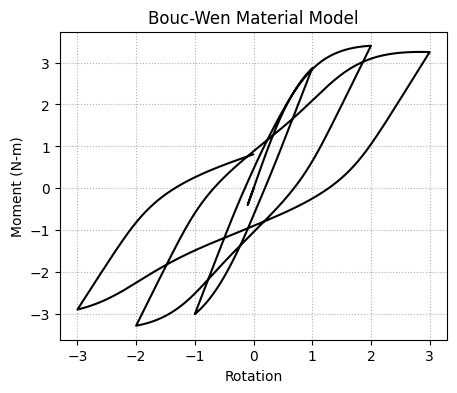

In [2]:
# Create plastic hinge model
# Regular Bouc-Wen model
'''plastic_hinge = BoucWen([
    0.1, # alpha
    0.2, # gamma
    1.0, # beta
    5.0, # n
    10.0  # k
    ])'''

# Modified Bouc-Wen model
parameters = [
    0.5,  # eta1
    4.0,  # k0
    4.0,  # sy0
    0.25,  # sig
    0.25,  # lam
    2.0,  # mup
    1.0,  # sigp
    0.6,  # rsmax
    2.0,  # n
    -0.05,  # alpha
    2.0,  # alpha1
    0.5,  # alpha2
    0.001   # betam1
]
plastic_hinge = DegradingBoucWen(parameters)

''' Pelliciari Bouc-Wen model
NL = 1.0

parameters = [
    38432000,  # Fy
    0.01,      # xu
    0.006,     # alpha
    38432000/0.001,  # ko
    1.28,      # n
    0.0,       # eta
    17000,  # beta
    0.0,       # rhoeps
    0.25,      # rhox
    1.6,       # phi
    15.0,      # deltak
    0.50,      # deltaf
    0.01,      # sigma
    4.0,       # u
    0.001,     # epsp
    0.1*0   # rhop
]
plastic_hinge = DegradingBoucWenPelliciari(parameters)'''

# Test the material model
strains = createCyclicStrain(maxStrains=[0.1, 1.0, 2.0, 3.0], dStrain=0.01)
strain_vec, stress_vec = material_test(plastic_hinge, strains[0])

# Plot the results
plt.figure(figsize=(5, 4))
plt.plot(strain_vec, np.array(stress_vec), label='Stress-Strain Curve', color='black')
plt.xlabel('Rotation')
plt.ylabel('Moment (N-m)')
plt.title('Bouc-Wen Material Model')
plt.grid(linestyle=':')

plastic_hinge.reset_state()

In [ ]:
# Let's test the new pushover analysis class
pushover = DispContPushoverAnalysis(
    controlnode=0,
    pref = np.array([1.0, 0.0, 0.0]),
    targetdisp=None,
    maxiter=1000,
    tol=1e-6
)

deltaMax = 0.05*6
maxStrains = [1*deltaMax/8, 2*deltaMax/8, 3*deltaMax/8, 4*deltaMax/8, 5*deltaMax/8, 6*deltaMax/8, 7*deltaMax/8, deltaMax]
pushover.set_target_displacements(maxStrains=maxStrains, dStrain=deltaMax/8/5)  # Set target displacement

# Reset the plastic hinge
plastic_hinge.reset_state()
E = 31.6e9  # GPa
I = 0.9 * 0.1825  # m4
h = 6.0
zeta = [0.02]  # Damping ratio

# Create the structure model
model = InelasticFrame(
    ncolumns=1,
    E=E,
    I=I,
    h=h,
    hingedata=[plastic_hinge] * 1,
    massdata=[1.0, 0.1, 0.1],
    damping=zeta,
    weight=0.0*30000000.0,  # Assuming a unit weight for simplicity
    geometry="p-delta"
)

pushover.run(model)
pushover.plot_pushover_curve()
pushover.save_results('pushover_results.csv')

In [ ]:
# Re-create the plot of force-vs-displacement

plt.figure(figsize=(5, 4))
plt.plot(np.array(pushover.targetdisp)/6, 2*np.array(pushover.lambdas), linestyle='--', color='red')
plt.xlabel(r'Drift Ratio ($\Delta/h$)')
plt.ylabel(r'Shear Force (MN)')
plt.grid()
plt.show()



In [ ]:
# Now, do the time-history analysis...

# Location of NGA-West2 ground motion files
gm_dir = r"C:\Users\Miguel.MIGUEL-DESK\Documents\PhD Files\RegionalSimulationResults\NGAWest2\json_files"

# List all ground motions
all_gms = os.listdir(gm_dir)

# Select a ground motion 
sel_gm = 20

# Load the selected ground motion
with open(os.path.join(gm_dir, all_gms[sel_gm]), 'r') as f:
    gm_data = json.load(f)

# pprint.pprint(gm_data)

dT = gm_data['dT']
# Create the time vector
t = np.arange(0, len(gm_data['data_x']) * dT, dT)
sf = 2.0

plt.figure(figsize=(6, 4))
plt.plot(t, sf * np.array(gm_data['data_x']), label='(X)', color='black', linewidth=0.5)
plt.plot(t, sf * np.array(gm_data['data_y']), label='(Y)', color='blue', linewidth=0.5)
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (g)')
plt.title(f'Selected NGA-West2 Ground Motion {all_gms[sel_gm]}')
plt.grid(linestyle=':')

In [ ]:
# Create time-history solver
th_solver = TH_Solver(dt=dT, maxiter=100)
ncolumns = 1

E = 30.6e9 # Pa
h = 5.5 # m
I = 0.6*0.1825  # m4

m = 262914*1.3  # kg
weight = [m*9.81]  # N
results = {}
for pv_val in weight:
    # Restart the plastic hinge state
    plastic_hinge.reset_state()

    # Create the structure model
    massdata = [m, 0.5*m, m*7.0]  # kg
    damping = [0.012]
    hinge_data = [plastic_hinge] * 1 * ncolumns
    model = InelasticFrame(
        ncolumns, E, I, h, hinge_data, massdata, damping, pv_val, geometry="p-delta"
    )

    model.eig()

    iota = np.array([1.0, 0.0, 0.0])

    # Pad ground motion data with zeros to add 2 seconds of zero acceleration at the end
    gm = gm_data['data_x'] # + [0.0] * int(5 / dT)
    gm = np.array(gm) * 9.81 # m/s^2
    t = np.arange(0, len(gm) * dT, dT)

    u1 = []
    mom = []
    rot = []
    plat = []

    for i in range(len(t)):
        # Get the current ground motion acceleration
        acc = sf * gm[i]
        
        # Calculate the force vector
        pf = - model.mass @ iota * acc
        
        # Perform the time step
        th_solver.step_increment(model, pf)
        u1.append(model.cstate['un'][0])
        rot.append(model.cstate['un'][1])
        mom.append(model.cstate['stress'][-1])
        plat.append(model.cstate['pr'][0])
    
    results[pv_val] = {
        't': t,
        'u1': u1,
        'rot': rot,
        'mom': mom,
        'plat': plat
    }

# Example: plot displacement for pv=0.15
t = results[pv_val]['t']
u1 = results[pv_val]['u1']


plt.figure(figsize=(6, 4))
plt.plot(t, np.array(u1) / h, label='Displacement', color='red', linewidth=0.5)
plt.xlabel('Time (s)')
plt.ylabel('Displacement (in)')
plt.title('Displacement Response to Ground Motion')
plt.grid(linestyle=':')
plt.show()


In [ ]:
model.eig()

In [ ]:
# Plot rotation vs moment for both pv cases
colors = ['black', 'blue', 'red', 'green', 'orange']
plt.figure(figsize=(6, 5))
for idx, pv_case in enumerate(results.keys()):
    rot = results[pv_case]['rot']
    mom = results[pv_case]['mom']
    plt.plot(rot, mom, label=fr'pv={pv_case}', color=colors[idx % len(colors)], linewidth=1.0, linestyle='-.')

plt.xlabel('Rotation')
plt.ylabel('Moment')
plt.title('Rotation vs Moment for Time-History Analysis')
plt.grid(linestyle=':')
plt.legend()
plt.show()

In [ ]:
# Plot u1 vs plat for both pv cases
plt.figure(figsize=(6, 5))
colors = [[0.2, 0.5, 0.3], [0.3, 0.3, 0.7]]
for idx, pv_case in enumerate(results.keys()):
    u1 = results[pv_case]['u1']
    plat = results[pv_case]['plat']
    plt.plot(-np.array(u1) / h, -np.array(plat), color=colors[idx % len(colors)], linewidth=1.0, linestyle='-.')
    plt.axvline(x=0.0, color='gray', linestyle='--', linewidth=0.5)
    plt.axhline(y=0.0, color='gray', linestyle='--', linewidth=0.5)
    
plt.xlabel('Drift Ratio')
plt.ylabel('Shear')
plt.title('Base Shear vs Displacement')
plt.grid(linestyle=':')
#plt.legend()
plt.show()

# Save the base shear vs displacement data to a csv file
import pandas as pd

data = []
for pv_case in results.keys():
    u1 = results[pv_case]['u1']
    plat = results[pv_case]['plat']
    for drift, shear in zip(u1, plat):
        data.append({'Drift Ratio': drift, 'Base Shear': shear, 'PV Case': pv_case})

df = pd.DataFrame(data)
df.to_csv('base_shear_vs_displacement.csv', index=False)

In [ ]:
def load_results(path):
    baseName = f'{path}/response'
    dispFileName = baseName + '_Top_Dsp.out'
    basedispFileName = baseName + '_Base_Dsp.out'
    reactionFileName = baseName + '_Reactions.out'
    baserotFilename = baseName + '_Base_Rot.out'

    Disp = np.loadtxt(dispFileName, delimiter= ' ')
    BaseDisp = np.loadtxt(basedispFileName, delimiter= ' ')
    Reactions = np.loadtxt(reactionFileName, delimiter= ' ')
    BaseRot = np.loadtxt(baserotFilename, delimiter= ' ')

    # Force-Deformation
    latdis = np.array(Disp[:, 1]) - np.array(BaseDisp[:, 1])
    shear = -np.array(Reactions[:, 2])
    rot = np.array(BaseRot[:, 2]) - np.array(BaseRot[:, 1]) / 77.476  # Rotation at the base
    moment = np.array(Reactions[:, 5])
    t = np.array(Disp[:, 0])  # Time vector
    return latdis, shear, rot, moment, t

# Now, let's plot the OpenSees and the custom model results together

# First, pushover results
# Load OpenSees results
pushover_results_path = r'C:\Users\Miguel.MIGUEL-DESK\Documents\GitHub\bart_opensees_models\pushover'
latdis, shear, rot, moment, t = load_results(pushover_results_path)

# timehist_results_path = r'C:\Users\Miguel.MIGUEL-DESK\Documents\GitHub\bart_opensees_models\timehistory'



plt.figure(dpi=200, figsize=(4, 4))
plt.plot(np.array(pushover.targetdisp)/6, 2*np.array(pushover.lambdas), linestyle='--', color='red', label='BoucWen PH')
plt.plot(latdis/232, shear/100, label='OpenSees Fiber', color='black', linewidth=1.0, linestyle='--')
plt.xlabel(r'Drift Ratio ($\Delta/h$)')
plt.ylabel(r'Shear Force (MN)')
plt.grid(linestyle=':')
plt.legend()
plt.ylim(-10.0, 10.0)
# Save figure as pdf
plt.savefig('01_hysteresis_comp.pdf')


In [ ]:
# Now, let's plot the time history results
timehist_results_path = r'C:\Users\Miguel.MIGUEL-DESK\Documents\GitHub\bart_opensees_models\timehistory'
latdis, shear, rot, moment, t = load_results(timehist_results_path)

# Same plot as above but with time history results
plt.figure(dpi=200, figsize=(4, 4))
plt.plot(np.array(u1) / h, -np.array(mom)/1000000/2, linestyle='--', color='red', label='BoucWen PH')
plt.plot(latdis/232, shear/100, label='OpenSees Fiber', color='black', linewidth=1.0, linestyle='--')
plt.xlabel(r'Drift Ratio ($\Delta/h$)')
plt.ylabel(r'Shear Force (MN)')
plt.grid(linestyle=':')
plt.legend()
plt.ylim(-10.0, 10.0)
plt.savefig('02_hysteresis_comp_timehist.pdf')


In [ ]:
# Now, plot the drift ratio vs time
plt.figure(figsize=(6, 4), dpi=200)
pv_val = list(results.keys())[0]  # Use the first pv_val for plotting

time = results[pv_val]['t']
u1 = results[pv_val]['u1']
plt.subplot(2,1,1)
plt.plot(time, np.array(gm_data['data_x'])*sf, label='Ground Motion RSN1013', color='blue', linewidth=0.5)
plt.grid(linestyle=':')
plt.legend()
plt.ylim(-1.0, 1.0)
plt.ylabel('Acc. (g)')
plt.subplot(2,1,2)
plt.plot(time, -np.array(u1) / h, label=f'Custom BW-PH', linewidth=0.5, color='red')
plt.plot(t, -np.array(latdis)/232, label='OpenSees Fiber', color='black', linewidth=1.0, linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel(r'Drift Ratio $(\Delta/h)$')
plt.grid(linestyle=':')
plt.legend()
plt.ylim([-0.02, 0.02])
plt.tight_layout()
plt.savefig('03_drift_ratio_vs_time.pdf')

